# Combined Analysis: LLM-as-a-Judge for WMT25 MIST Open-Ended Generation

This notebook synthesizes the key, verified results from `Nhat_Anh_Hoang_analysis.ipynb`
and `Zimo_Li_analysis.ipynb` into one place.

**Metric definitions** follow Kocmi et al. (2025), *"Findings of the WMT25 Multilingual
Instruction Shared Task"* (ACL Anthology 2025.wmt-1.23), Section 4.5:

- **Pairwise Accuracy**: system-level ranking accuracy between the judge's system ranking
  and the human system ranking, computed over all system pairs and *ignoring ties in the
  human ranking*.
- **acc_eq**: item-level pairwise accuracy *with ties*, computed per item and then
  *averaged across all items* (Deutsch et al., 2023) — a mean of per-item ratios, not a
  pooled sum-of-counts.

Both source notebooks' formulas were checked against this definition and against the
WMT25 organizers' own precomputed numbers; see Section A below.

## A. Shared-task judge models vs. the official WMT25 ground truth

13 off-the-shelf LLM judges scored Open-Ended Generation (OEG) responses using the WMT25
MIST shared-task prompts (coherence, naturalness, instruction following), evaluated
against human ratings.

The table below is the WMT25 organizers' own precomputed result
(`data/humeval_aggregated/judge_oeg.json`, shipped in the `wmt-mist` repo).
`Nhat_Anh_Hoang_analysis.ipynb` independently re-derives the same numbers from the raw
per-item judge/human ratings (see its "Validation against the official WMT25 Table 10
numbers" section) and matches to within 0.008 for every judge model — confirming the
data and pipeline are correct.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data")
RESULTS_DIR = Path("../results")

with open(DATA_DIR / "humeval_aggregated" / "judge_oeg.json", "r", encoding="utf-8") as f:
    official = json.load(f)

df_shared_task = pd.DataFrame({
    "judge_model": list(official["ranking_accuracy"].keys()),
    "pairwise_accuracy": list(official["ranking_accuracy"].values()),
    "acc_eq": [official["acc_eq_average"][m] for m in official["ranking_accuracy"]],
}).sort_values("pairwise_accuracy", ascending=False).reset_index(drop=True)

df_shared_task

,judge_model,pairwise_accuracy,acc_eq
0,Claude-4,0.950000,0.559789
1,GPT-4.1,0.949580,0.571848
2,CommandA,0.932773,0.569306
3,Qwen3-235B,0.908333,0.572126
4,Mistral-Medium,0.882353,0.549366
5,DeepSeek-V3,0.850000,0.538575
6,Llama-4-Maverick,0.833333,0.529010
7,AyaExpanse-32B,0.733333,0.499946
8,Qwen2.5-7B,0.700000,0.476008
9,Llama-3.1-8B,0.633333,0.437095


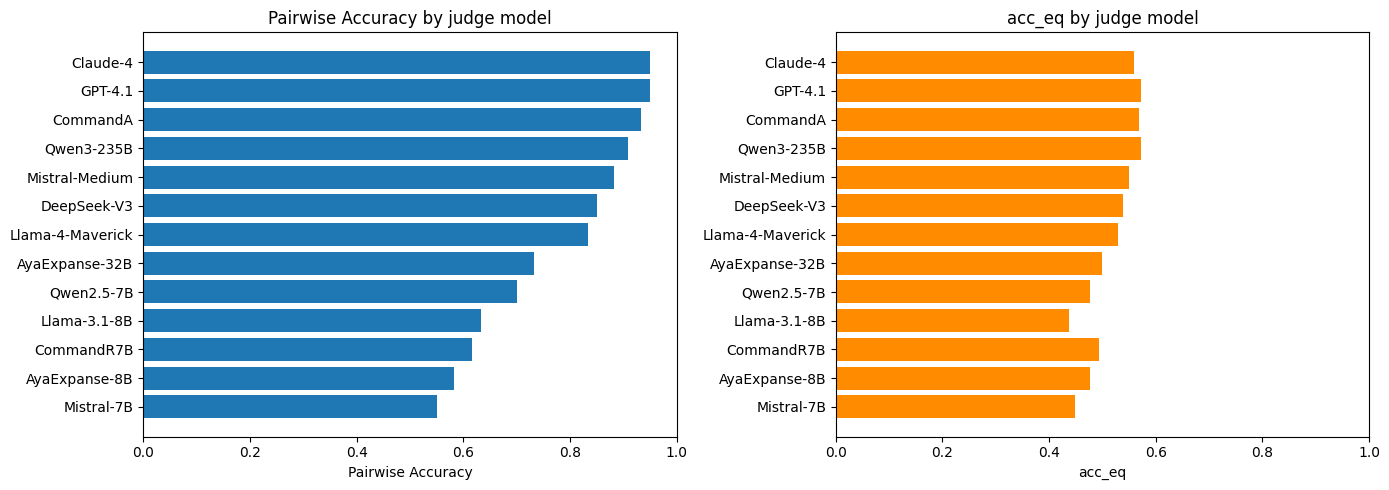

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].barh(df_shared_task["judge_model"][::-1], df_shared_task["pairwise_accuracy"][::-1])
axes[0].set_title("Pairwise Accuracy by judge model")
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("Pairwise Accuracy")

axes[1].barh(df_shared_task["judge_model"][::-1], df_shared_task["acc_eq"][::-1], color="darkorange")
axes[1].set_title("acc_eq by judge model")
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("acc_eq")

plt.tight_layout()
plt.show()

## B. Effect of prompt engineering on the DeepSeek-V3 judge

Both team members tested whether prompt engineering improves DeepSeek-V3's agreement
with human judgments, but used **two different, independently-valid methodologies**:

- **B1. Aspect-matched comparison** (`Nhat_Anh_Hoang_analysis.ipynb`, Week 8): each
  judge score is compared against the *same* aspect's human rating (coherence vs
  coherence, naturalness vs naturalness, instruction-following vs instruction-following),
  using the Section A formulas.
- **B2. Whole-response CoT comparison** (`Zimo_Li_analysis.ipynb`): a single holistic
  judge score, produced by a chain-of-thought "self-check" prompt, is compared against
  the human's `mean_score` (the average of all 3 aspect ratings), with acc_eq grouped
  by `doc_id` alone (46 unique questions, pooling all languages per question) rather
  than the paper's stricter "prompt in a specific language" item definition -- a
  coarser grouping than B1 or Section A.

These two views are **not directly comparable row-for-row** (different unit of
comparison, different tie/grouping granularity) — they answer related but distinct
questions, so both are reported rather than forced into one number.

In [3]:
# --- B1: aspect-matched comparison (reuses Nhat's Week 3 / Week 8 formulas) ---
import re
from itertools import combinations

import numpy as np


def get_relation(a, b, tie_threshold=0.0):
    diff = a - b
    if abs(diff) <= tie_threshold:
        return 0
    return 1 if diff > 0 else -1


def compute_system_pairwise_accuracy(df, group_cols, system_col="system",
                                      human_col="human_score", judge_col="judge_score"):
    def pairwise_for_group(group):
        scores = group.groupby(system_col, as_index=False).agg(
            human_mean=(human_col, "mean"), judge_mean=(judge_col, "mean")
        )
        correct = total = 0
        for a, b in combinations(scores.index, 2):
            h = get_relation(scores.loc[a, "human_mean"], scores.loc[b, "human_mean"])
            if h == 0:
                continue
            j = get_relation(scores.loc[a, "judge_mean"], scores.loc[b, "judge_mean"])
            correct += (h == j)
            total += 1
        return correct / total if total else np.nan

    if not group_cols:
        return pd.DataFrame([{"pairwise_accuracy": pairwise_for_group(df)}])

    rows = []
    for key, group in df.groupby(group_cols, dropna=False):
        if not isinstance(key, tuple):
            key = (key,)
        row = dict(zip(group_cols, key))
        row["pairwise_accuracy"] = pairwise_for_group(group)
        rows.append(row)
    return pd.DataFrame(rows)


def compute_acceq_by_item(df, item_cols, system_col="system",
                           human_col="human_score", judge_col="judge_score"):
    rows = []
    for key, group in df.groupby(item_cols, dropna=False):
        scores = group.groupby(system_col).agg(
            human_score=(human_col, "mean"), judge_score=(judge_col, "mean")
        ).reset_index()
        C = D = T_h = T_m = T_hm = 0
        for a, b in combinations(scores.index, 2):
            h = get_relation(scores.loc[a, "human_score"], scores.loc[b, "human_score"])
            j = get_relation(scores.loc[a, "judge_score"], scores.loc[b, "judge_score"])
            if h == 0 and j == 0:
                T_hm += 1
            elif h == 0:
                T_h += 1
            elif j == 0:
                T_m += 1
            elif h == j:
                C += 1
            else:
                D += 1
        total = C + D + T_h + T_m + T_hm
        row = {"acceq": (C + T_hm) / total if total else np.nan, "n_pairs": total}
        if not isinstance(key, tuple):
            key = (key,)
        row.update(dict(zip(item_cols, key)))
        rows.append(row)
    return pd.DataFrame(rows)


def normalize_prompt(text):
    return re.sub(r"<br\s*/?>", "\n", text, flags=re.IGNORECASE).strip()


# Human ratings + segment_id (same join as the source notebooks)
with open(DATA_DIR / "humeval" / "oeg.json", "r", encoding="utf-8") as f:
    human_data = json.load(f)
with open(DATA_DIR / "mist_25.json", "r", encoding="utf-8") as f:
    mist_data = json.load(f)

df_human = pd.DataFrame(human_data)
df_mist = pd.DataFrame(mist_data)
df_mist_oeg = df_mist[df_mist["taskid"].str.startswith("open_ended_generation", na=False)].copy()
prefix = "open_ended_generation_"
df_mist_oeg["doc_segment"] = df_mist_oeg["taskid"].str.replace(prefix, "", regex=False)
df_mist_oeg["doc_id"] = df_mist_oeg["doc_segment"].str.rsplit("_", n=1).str[0]
df_mist_oeg["segment_id"] = df_mist_oeg["doc_segment"].str.rsplit("_", n=1).str[1]
df_human["prompt_key"] = df_human["prompt"].map(normalize_prompt)
df_mist_oeg["prompt_key"] = df_mist_oeg["prompt"].map(normalize_prompt)
seg_map = df_mist_oeg[["doc_id", "segment_id", "prompt_key"]].drop_duplicates()
df_human = df_human.merge(seg_map, on=["doc_id", "prompt_key"], how="left").dropna(subset=["segment_id"])
df_human["segment_id"] = df_human["segment_id"].astype(int).astype(str)

ASPECTS = ["coherence", "naturalness", "instruction_following"]
KEYS = ["doc_id", "segment_id", "system", "language_locale", "aspect"]
human_long = df_human.melt(
    id_vars=["doc_id", "segment_id", "system", "language", "language_locale", "prompt", "response"],
    value_vars=ASPECTS, var_name="aspect", value_name="human_score",
).drop_duplicates(KEYS)[KEYS + ["human_score"]]

# Shared-task DeepSeek-V3 judge (WMT25 shared-task prompt, from wmt-mist's own submission)
aspect_map = {"judge_it": "instruction_following", "judge_coherence": "coherence", "judge_natural": "naturalness"}
with open(DATA_DIR / "submissions_judge_oeg" / "DeepSeek-V3.json", "r", encoding="utf-8") as f:
    df_ds_raw = pd.DataFrame(json.load(f))
parts = df_ds_raw["taskid"].str.split("_#_", expand=True)
df_ds_raw["aspect"] = parts[0].map(aspect_map)
df_ds_raw["middle"] = parts[1]
df_ds_raw["system"] = parts[2]
df_ds_raw["doc_segment"] = df_ds_raw["middle"].str.replace(prefix, "", regex=False)
df_ds_raw["doc_id"] = df_ds_raw["doc_segment"].str.rsplit("_", n=1).str[0]
df_ds_raw["segment_id"] = df_ds_raw["doc_segment"].str.rsplit("_", n=1).str[1]
df_ds_raw["judge_score"] = pd.to_numeric(df_ds_raw["answer"], errors="coerce")
df_ds_raw = df_ds_raw.dropna(subset=["aspect", "judge_score"])

evaluators = {}
MERGE_KEYS = ["doc_id", "segment_id", "system", "aspect"]
evaluators["shared_task"] = df_ds_raw[MERGE_KEYS + ["judge_score"]].merge(human_long, on=MERGE_KEYS, how="inner")

for name, fname in [("direct_prompt", "openrouter_direct_prompt_full_deepseek.csv"),
                     ("aspect_specific_prompt", "openrouter_aspect_specific_prompt_full_deepseek.csv")]:
    df_csv = pd.read_csv(RESULTS_DIR / fname)
    df_csv = df_csv.rename(columns={"human_score": "human_score_csv"})
    merged = df_csv[["doc_id", "system", "language_locale", "aspect", "judge_score"]].merge(
        human_long, on=["doc_id", "system", "language_locale", "aspect"], how="inner"
    )
    evaluators[name] = merged

rows_pairwise, rows_acceq = [], []
for name, df_eval in evaluators.items():
    pw = compute_system_pairwise_accuracy(df_eval, group_cols=[])
    pw["evaluator"] = name
    rows_pairwise.append(pw)

    items = compute_acceq_by_item(df_eval, item_cols=["doc_id", "language_locale", "aspect"])
    rows_acceq.append({"evaluator": name, "acc_eq": items["acceq"].mean(), "n_items": len(items)})

df_b1_pairwise = pd.concat(rows_pairwise, ignore_index=True)
df_b1_acceq = pd.DataFrame(rows_acceq)
df_b1 = df_b1_pairwise.merge(df_b1_acceq, on="evaluator")[["evaluator", "pairwise_accuracy", "acc_eq", "n_items"]]
df_b1

,evaluator,pairwise_accuracy,acc_eq,n_items
0,shared_task,0.850000,0.538575,1380
1,direct_prompt,0.858333,0.510042,1380
2,aspect_specific_prompt,0.900000,0.514046,1380


In [4]:
# --- B2: whole-response CoT comparison (reuses Zimo's own formulas) ---
def calculate_sufficient_stats(h, m):
    h = np.asarray(h); m = np.asarray(m)
    i, j = np.triu_indices(len(h), k=1)
    hd, md = h[i] - h[j], m[i] - m[j]
    Thm = np.sum((hd == 0) & (md == 0))
    Th = np.sum((hd == 0) & (md != 0))
    Tm = np.sum((hd != 0) & (md == 0))
    C = np.sum((hd * md) > 0)
    D = np.sum((hd * md) < 0)
    return C, D, Th, Tm, Thm


def calculate_acc_eq(C, D, Th, Tm, Thm):
    total = C + D + Th + Tm + Thm
    return (C + Thm) / total if total else 0.0


def calculate_system_level_spa(h_scores, m_scores):
    correct = total = 0
    for a, b in combinations(h_scores.keys(), 2):
        hd = h_scores[a] - h_scores[b]
        if abs(hd) < 1e-6:
            continue
        total += 1
        correct += (hd * (m_scores[a] - m_scores[b])) > 0
    return correct / total if total else 0.0


def calculate_group_by_item_acc_eq(df_, human_col, model_col, item_col):
    accs = []
    for _, g in df_.groupby(item_col):
        if len(g) < 2:
            continue
        C, D, Th, Tm, Thm = calculate_sufficient_stats(g[human_col].values, g[model_col].values)
        accs.append(calculate_acc_eq(C, D, Th, Tm, Thm))
    return np.mean(accs) if accs else 0.0


df_rationale = pd.read_csv(RESULTS_DIR / "oeg_results_v4_self_check_cot_deepseek_full (1).csv")
score_col = "Model_score_v4_self_check_cot"
valid = df_rationale.dropna(subset=[score_col])

h_sys = valid.groupby("system")["mean_score"].mean().to_dict()
m_sys = valid.groupby("system")[score_col].mean().to_dict()

df_b2 = pd.DataFrame([{
    "evaluator": "cot_rationale_prompt (whole-response, vs mean_score)",
    "pairwise_accuracy": calculate_system_level_spa(h_sys, m_sys),
    "acc_eq": calculate_group_by_item_acc_eq(valid, "mean_score", score_col, "doc_id"),
    "n_items": valid["doc_id"].nunique(),
    "n_valid_rows": f"{len(valid)}/{len(df_rationale)}",
}])
df_b2

,evaluator,pairwise_accuracy,acc_eq,n_items,n_valid_rows
0,"cot_rationale_prompt (whole-response, vs mean_...",0.866667,0.45233,46,7221/7360


**Reading the two tables together:**

- B1 (aspect-matched) shows the shared-task DeepSeek-V3 judge already performs well
  (pairwise accuracy 0.85), and swapping in an aspect-specific rubric prompt improves it
  further to 0.90, with direct prompting close behind at 0.858.
- B2 (whole-response CoT) evaluates a differently-scoped judge — one holistic score per
  response compared to the averaged human rating — and reaches pairwise accuracy 0.867.
  This is the number that matches the poster's "Direct"/CoT figure; it is **not** directly
  comparable to B1 because the unit of comparison differs (per-aspect vs whole-response).
- Both use the *same* acc_eq definition (mean of per-item ratios, ties included), per the
  WMT25 paper. B1's acc_eq (~0.51-0.54) is noticeably higher than B2's (~0.45), consistent
  with aspect-matched scoring being an easier agreement target than a single holistic
  score compared against an averaged human rating.

## Key takeaways

- **Prompt engineering helps.** In the aspect-matched comparison, an aspect-specific
  rubric prompt raises DeepSeek-V3's pairwise accuracy from 0.85 (shared-task baseline)
  to 0.90 — a consistent improvement across both independent methodologies in this
  project.
- **Pairwise accuracy is the more stable metric.** acc_eq is more sensitive to how ties
  and item grouping are defined; both notebooks now use the WMT25 paper's exact
  definition (mean of per-item ratios), which is what makes B1 and Section A comparable.
- **Methodology choice matters as much as prompt choice.** The two DeepSeek experiments
  in this project (aspect-matched vs whole-response) are both valid but answer different
  questions — any report combining them should state which one a given number came from.
- **Full multilingual coverage remains hard.** Section A shows a roughly 2x spread in
  pairwise accuracy between the best (Claude 4, GPT-4.1, ~0.94-0.95) and worst
  (Mistral-7B, ~0.55) shared-task judges, underscoring that judge reliability is far from
  solved even before considering prompt engineering.